In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
project_root = os.path.abspath("..")
sys.path.append(project_root)

print("Added to PYTHONPATH:", project_root)

Added to PYTHONPATH: /vols/cms/mm1221/geant4sim/scripts/validation_new


In [28]:
import pandas as pd
import glob
import os
from pathlib import Path

def load_csv_folder_with_event_offset(folder, event_col="event_id", verbose=True):
    """
    Recursively loads ALL CSVs inside `folder` and subfolders.
    Applies a running offset to event_id so events remain unique across files.
    """

    pattern = os.path.join(folder, "**", "*.csv")
    csv_files = glob.glob(pattern, recursive=True)

    if len(csv_files) == 0:
        raise RuntimeError(f"No CSV files found anywhere under {folder}")

    csv_files = sorted(csv_files, key=lambda p: Path(p).as_posix())

    if verbose:
        print(f"Found {len(csv_files)} csv files")

    dfs = []
    event_offset = 0
    total_events = 0

    for i, f in enumerate(csv_files):
        if verbose and (i % 20 == 0):
            print(f"[{i+1}/{len(csv_files)}] Loading: {f}")

        df = pd.read_csv(f)

        if event_col not in df.columns:
            raise ValueError(f"{event_col} not found in {f}")

        n_events = df[event_col].nunique()

        df[event_col] += event_offset

        dfs.append(df)

        event_offset += n_events
        total_events += n_events

    if verbose:
        print(f"Total unique events loaded: {total_events}")
        print(f"Final event_id range: 0 → {event_offset-1}")

    return pd.concat(dfs, ignore_index=True)

In [41]:
df_contrastive = load_csv_folder_with_event_offset("../csv_EM_all/cont_agg_k10")
df_oc          = load_csv_folder_with_event_offset("../dfs_oc/")
df_oc_Ag          = load_csv_folder_with_event_offset("../csv_EM_all/oc_agg_k11")
df_oc_noise = load_csv_folder_with_event_offset("../csv_EM_all/cont_density")


print(df_contrastive["event_id"].min(), df_contrastive["event_id"].max())
print(df_oc["event_id"].min(), df_oc["event_id"].max())
print(df_oc_Ag["event_id"].min(), df_oc_Ag["event_id"].max())
print(df_oc_noise["event_id"].min(), df_oc_noise["event_id"].max())

Found 320 csv files
[1/320] Loading: ../csv_EM_all/cont_agg_k10/Test_pi.1001_1002.csv
[21/320] Loading: ../csv_EM_all/cont_agg_k10/Test_pi.1039_1040.csv
[41/320] Loading: ../csv_EM_all/cont_agg_k10/Test_pi.1075_1076.csv
[61/320] Loading: ../csv_EM_all/cont_agg_k10/Test_pi.1111_1112.csv
[81/320] Loading: ../csv_EM_all/cont_agg_k10/Test_pi.1147_1148.csv
[101/320] Loading: ../csv_EM_all/cont_agg_k10/Test_pi.1183_1184.csv
[121/320] Loading: ../csv_EM_all/cont_agg_k10/Test_pi.1219_1220.csv
[141/320] Loading: ../csv_EM_all/cont_agg_k10/Test_pi.1255_1256.csv
[161/320] Loading: ../csv_EM_all/cont_agg_k10/Test_pi.1291_1292.csv
[181/320] Loading: ../csv_EM_all/cont_agg_k10/Test_pi.1327_1328.csv
[201/320] Loading: ../csv_EM_all/cont_agg_k10/Test_pi.1363_1364.csv
[221/320] Loading: ../csv_EM_all/cont_agg_k10/Test_pi.139_140.csv
[241/320] Loading: ../csv_EM_all/cont_agg_k10/Test_pi.1435_1436.csv
[261/320] Loading: ../csv_EM_all/cont_agg_k10/Test_pi.1471_1472.csv
[281/320] Loading: ../csv_EM_all/con

/tmp/ipykernel_3272235/416093720.py:214: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


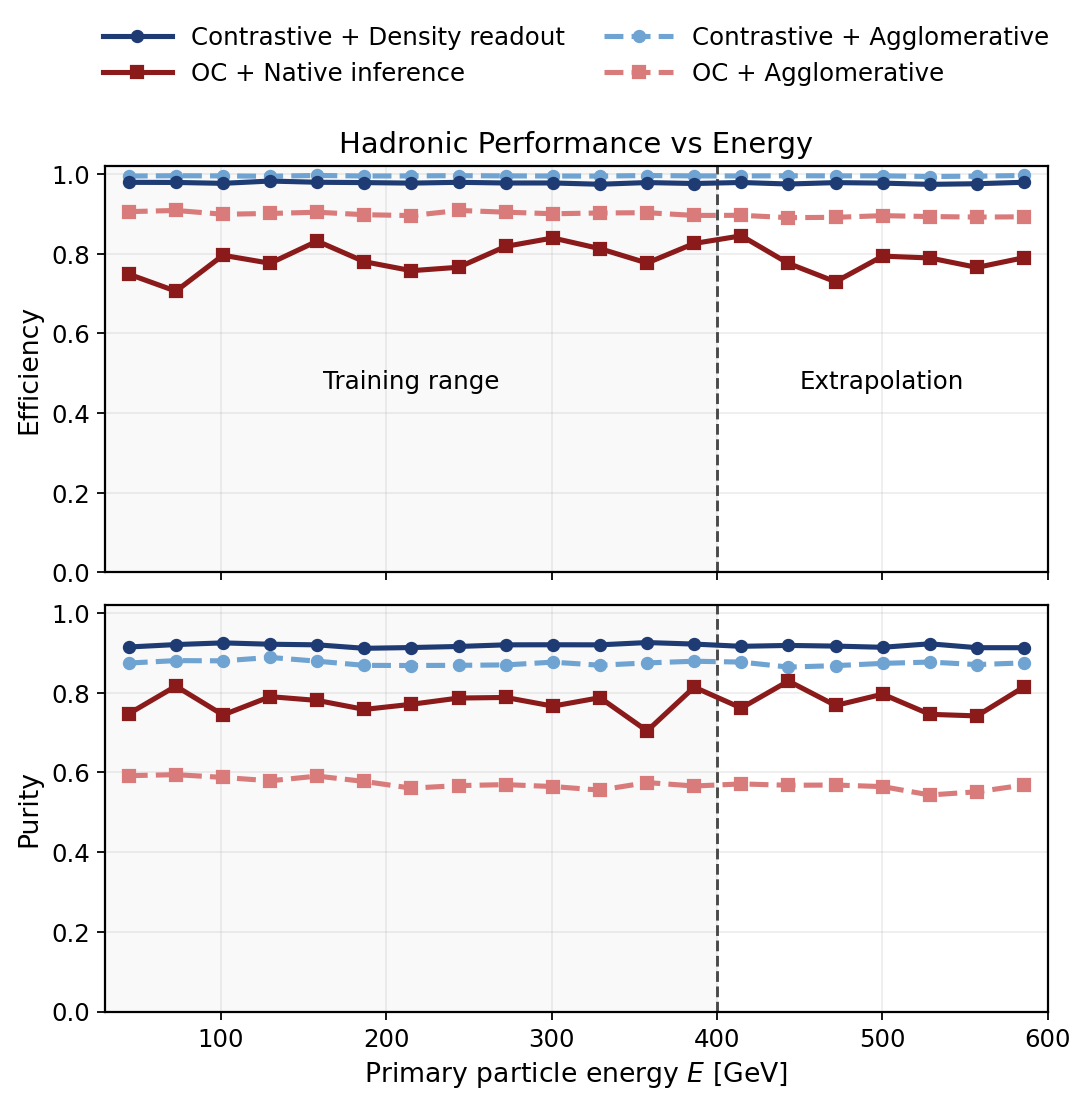

In [42]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from src.metrics.calculations import calc_efficiency, calc_purity


mpl.rcParams.update({
    "figure.dpi": 160,
    "savefig.dpi": 300,
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.linewidth": 1.0,
    "lines.linewidth": 2.3,
    "lines.markersize": 5.0,
})

def _major_grid(ax):
    ax.grid(True, which="major", alpha=0.22, linewidth=0.8)
    ax.minorticks_off()


EVENT_COL   = "event_id"
RECO_ID_COL = "reco_id"
CP_ID_COL   = "cp_id"
RTS_COL     = "RtS"           
CP_E_COL    = "PrimaryEnergy" 


METHODS = [
    ("Contrastive + Density readout",   df_oc_noise),     
    ("OC + Native inference",           df_oc),           
    ("Contrastive + Agglomerative",     df_contrastive),  
    ("OC + Agglomerative",              df_oc_Ag),     
]

BLUE_DARK  = "#1f3b73"
BLUE_LIGHT = "#6fa3d2"
RED_DARK   = "#8b1a1a"
RED_LIGHT  = "#d97b7b"

STYLE = {
    "Contrastive + Density readout": dict(color=BLUE_DARK,  linestyle="-",  marker="o", zorder=5),
    "OC + Native inference":         dict(color=RED_DARK,   linestyle="-",  marker="s", zorder=5),
    "Contrastive + Agglomerative":   dict(color=BLUE_LIGHT, linestyle="--", marker="o", zorder=3),
    "OC + Agglomerative":            dict(color=RED_LIGHT,  linestyle="--", marker="s", zorder=3),
}


def attach_best_cp_energy(df,
                          *,
                          event_col=EVENT_COL,
                          reco_col=RECO_ID_COL,
                          cp_col=CP_ID_COL,
                          rts_col=RTS_COL,
                          cp_energy_col=CP_E_COL):
    """
    One row per (event_id, reco_id):
      choose cp_id with MINIMUM RtS, attach that cp's energy as matched_cp_energy.
    """
    needed = {event_col, reco_col, cp_col, rts_col, cp_energy_col}
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"attach_best_cp_energy missing columns: {missing}")

    d = df[[event_col, reco_col, cp_col, rts_col, cp_energy_col]].copy()
    d = d[np.isfinite(d[rts_col].to_numpy()) & np.isfinite(d[cp_energy_col].to_numpy())]

    idx = d.groupby([event_col, reco_col], sort=False)[rts_col].idxmin()
    best = d.loc[idx, [event_col, reco_col, cp_col, rts_col, cp_energy_col]].copy()
    best = best.rename(columns={cp_energy_col: "matched_cp_energy"})
    return best

def filter_df_to_reco_set(df, reco_set_df, *, event_col=EVENT_COL, reco_col=RECO_ID_COL):
    """Keep only association rows for reco objects in reco_set_df (event_id,reco_id)."""
    return df.merge(reco_set_df[[event_col, reco_col]], on=[event_col, reco_col], how="inner")

# Fixed binning 
n_bins = 20
E_MIN_GEV = 30.0
E_MAX_GEV = 600.0

cp_bins = np.linspace(E_MIN_GEV * 1000.0, E_MAX_GEV * 1000.0, n_bins + 1)  # MeV
cp_bin_centers = 0.5 * (cp_bins[:-1] + cp_bins[1:])
xE_GeV = cp_bin_centers / 1000.0

# 1) Efficiency vs energy (
eff_vs_E = {name: [] for name, _ in METHODS}
for i in range(n_bins):
    low, high = cp_bins[i], cp_bins[i + 1]
    for name, df in METHODS:
        df_bin = df[(df[CP_E_COL] >= low) & (df[CP_E_COL] < high)]
        eff_vs_E[name].append(calc_efficiency(df_bin, threshold=0.7) if len(df_bin) else np.nan)

# 2) Purity vs matched CP energy (bin reco objects by best-matched CP energy)
best_maps = {name: attach_best_cp_energy(df) for name, df in METHODS}

pur_vs_E = {name: [] for name, _ in METHODS}
for i in range(n_bins):
    low, high = cp_bins[i], cp_bins[i + 1]
    for name, df in METHODS:
        best = best_maps[name]
        sel = best[(best["matched_cp_energy"] >= low) & (best["matched_cp_energy"] < high)]
        df_bin = filter_df_to_reco_set(df, sel)
        pur_vs_E[name].append(calc_purity(df_bin, threshold=0.2) if len(df_bin) else np.nan)



fig, (ax_eff, ax_pur) = plt.subplots(
    2, 1, figsize=(7.6, 7.0),
    sharex=True,
    gridspec_kw={"height_ratios": [1.0, 1.0], "hspace": 0.08},
)

#Efficiency (top)
for name, _df in METHODS:
    ax_eff.plot(xE_GeV, eff_vs_E[name], label=name, **STYLE[name])

ax_eff.set_title("Hadronic Performance vs Energy")
ax_eff.set_ylabel("Efficiency")
ax_eff.set_ylim(0.0, 1.02)
_major_grid(ax_eff)

#Purity (bottom)
for name, _df in METHODS:
    ax_pur.plot(xE_GeV, pur_vs_E[name], label=name, **STYLE[name])

ax_pur.set_xlabel(r"Primary particle energy $E$ [GeV]")
ax_pur.set_ylabel("Purity")
ax_pur.set_ylim(0.0, 1.02)
_major_grid(ax_pur)

ax_pur.set_xlim(E_MIN_GEV, E_MAX_GEV)

#Training split at 400 GeV 
split_GeV = 400.0
xmin, xmax = E_MIN_GEV, E_MAX_GEV

for ax in (ax_eff, ax_pur):
    ax.axvline(split_GeV, color="0.25", linestyle="--", linewidth=1.3, alpha=0.95)
    ax.axvspan(xmin, split_GeV, color="0.3", alpha=0.03, lw=0)
    ax.axvspan(split_GeV, xmax, color="0.3", alpha=0.00, lw=0)

# labels 
ax_eff.text(
    0.5 * (xmin + split_GeV),
    0.5,
    "Training range",
    ha="center",
    va="top",
    transform=ax_eff.get_xaxis_transform(),
    fontsize=11,
)
ax_eff.text(
    0.5 * (split_GeV + xmax),
    0.5,
    "Extrapolation",
    ha="center",
    va="top",
    transform=ax_eff.get_xaxis_transform(),
    fontsize=11,
)

# legend above the top plot 
ax_eff.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.40),
    ncol=2,
    columnspacing=1.6,
    handlelength=2.8,
)

plt.tight_layout()
plt.show()

#fig.savefig("Hadronic_Energy.pdf", bbox_inches="tight")

/tmp/ipykernel_3272235/3162492395.py:218: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


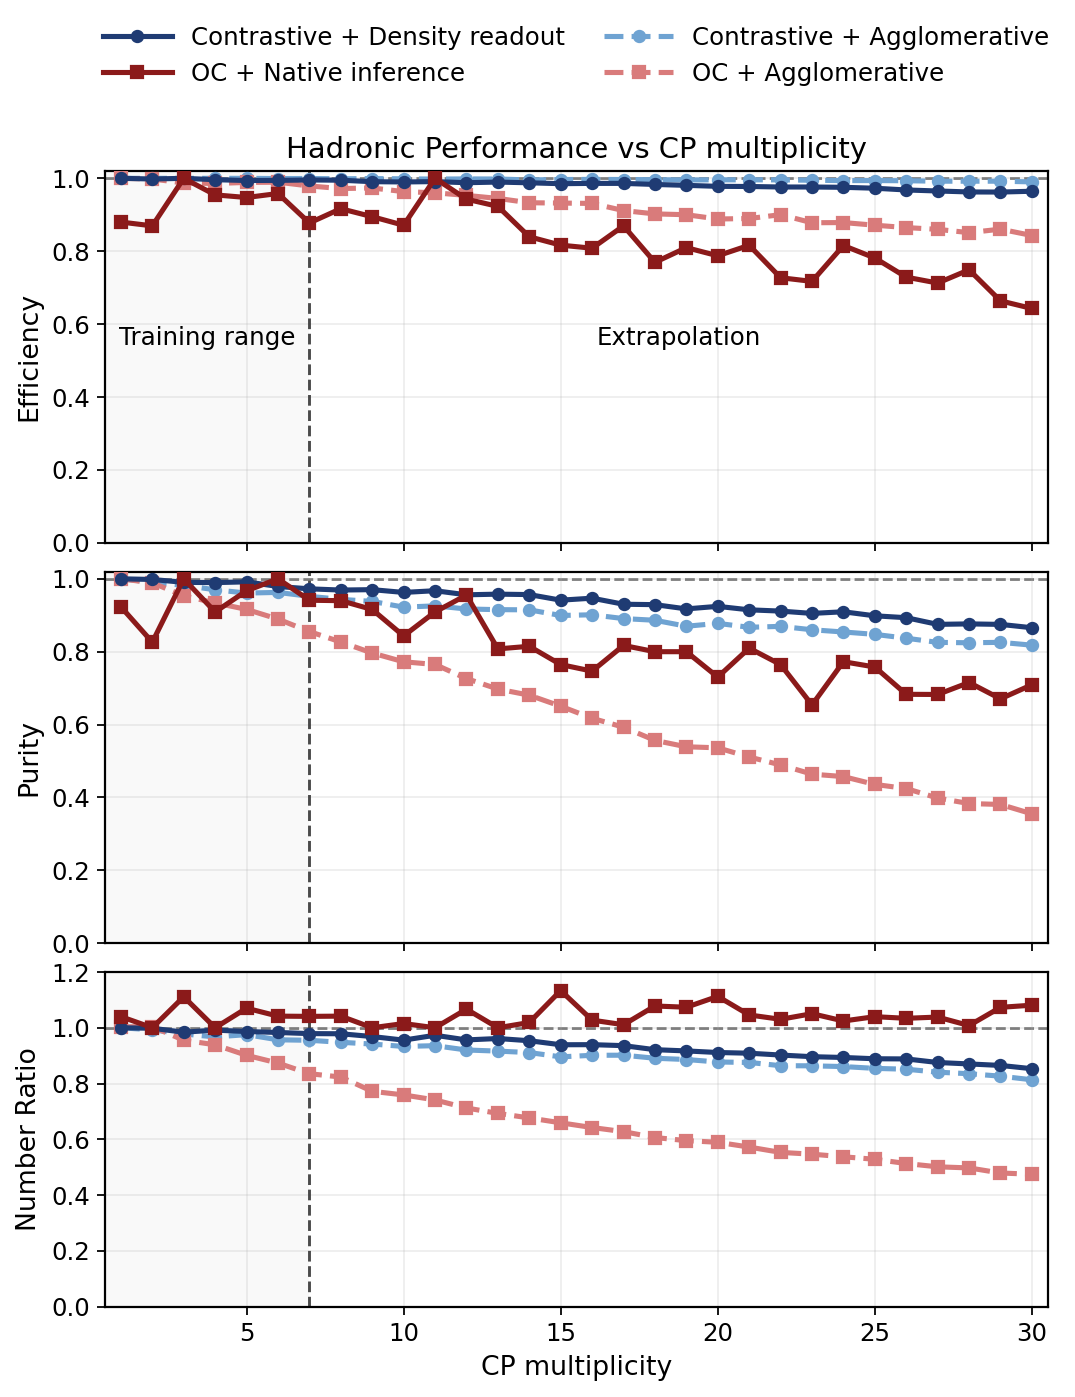

In [43]:
from src.metrics.calculations import calc_ratio



EVENT_COL   = "event_id"
CP_ID_COL   = "cp_id"
RECO_E_COL  = "reco_energy"

METHODS = [
    ("Contrastive + Density readout",  df_oc_noise), 
    ("OC + Native inference",          df_oc),         
    ("Contrastive + Agglomerative",    df_contrastive),
    ("OC + Agglomerative",             df_oc_Ag),       
]

BLUE_DARK  = "#1f3b73"
BLUE_LIGHT = "#6fa3d2"
RED_DARK   = "#8b1a1a"
RED_LIGHT  = "#d97b7b"

STYLE = {
    "Contrastive + Density readout": dict(color=BLUE_DARK,  linestyle="-",  marker="o", zorder=5),
    "OC + Native inference":         dict(color=RED_DARK,   linestyle="-",  marker="s", zorder=5),
    "Contrastive + Agglomerative":   dict(color=BLUE_LIGHT, linestyle="--", marker="o", zorder=3),
    "OC + Agglomerative":            dict(color=RED_LIGHT,  linestyle="--", marker="s", zorder=3),
}


cp_per_event = (
    df_contrastive[[EVENT_COL, CP_ID_COL]]
    .drop_duplicates()
    .groupby(EVENT_COL)[CP_ID_COL]
    .nunique()
)

xM = np.sort(cp_per_event.unique()) 

# 1) Efficiency vs CP multiplicity
eff_vs_M = {name: [] for name, _ in METHODS}
for m in xM:
    event_ids_m = cp_per_event.index[cp_per_event == m]
    for name, df in METHODS:
        df_m = df[df[EVENT_COL].isin(event_ids_m)]
        eff_vs_M[name].append(calc_efficiency(df_m, threshold=0.7) if len(df_m) else np.nan)


# 2) Purity vs CP multiplicity
LOW, HIGH = 0, 30000
pur_vs_M = {name: [] for name, _ in METHODS}
for m in xM:
    event_ids_m = cp_per_event.index[cp_per_event == m]
    for name, df in METHODS:
        df_res = df[(df[RECO_E_COL] >= LOW) & (df[RECO_E_COL] <= HIGH)]
        df_m = df_res[df_res[EVENT_COL].isin(event_ids_m)]
        pur_vs_M[name].append(calc_purity(df_m, threshold=0.2) if len(df_m) else np.nan)


# 3) Reco/CP ratio vs CP multiplicity
ratio_vs_M = {name: [] for name, _ in METHODS}
for m in xM:
    event_ids_m = cp_per_event.index[cp_per_event == m]
    for name, df in METHODS:
        df_m = df[df[EVENT_COL].isin(event_ids_m)]
        ratio_vs_M[name].append(calc_ratio(df_m) if len(df_m) else np.nan)

# Plot: 3 rows, shared x-axis
fig, (ax_eff, ax_pur, ax_rat) = plt.subplots(
    3, 1, figsize=(7.6, 9.4),
    sharex=True,
    gridspec_kw={"height_ratios": [1.0, 1.0, 0.9], "hspace": 0.08},
)

# Efficiency (top)
for name, _df in METHODS:
    ax_eff.plot(xM, eff_vs_M[name], label=name, **STYLE[name])
ax_eff.set_title("Hadronic Performance vs CP multiplicity")
ax_eff.set_ylabel("Efficiency")
ax_eff.set_ylim(0.0, 1.02)
_major_grid(ax_eff)

# Purity (middle)
for name, _df in METHODS:
    ax_pur.plot(xM, pur_vs_M[name], label=name, **STYLE[name])
ax_pur.set_ylabel("Purity")
ax_pur.set_ylim(0.0, 1.02)
_major_grid(ax_pur)

# Ratio (bottom)
for name, _df in METHODS:
    ax_rat.plot(xM, ratio_vs_M[name], label=name, **STYLE[name])
#ax_rat.axhline(1.0, color="0.35", linestyle="--", linewidth=1.1, alpha=0.8)
ax_rat.set_xlabel("CP multiplicity")
ax_rat.set_ylabel("Number Ratio")
ax_rat.set_ylim(0.0, 1.2)
_major_grid(ax_rat)

if len(xM):
    x_left  = float(np.min(xM)) - 0.5
    x_right = float(np.max(xM)) + 0.5
    ax_rat.set_xlim(x_left, x_right)

# Choose a sensible ratio y-range
all_rat = np.concatenate([np.asarray(ratio_vs_M[name], dtype=float) for name, _ in METHODS]) if len(xM) else np.array([1.0])
all_rat = all_rat[np.isfinite(all_rat)]
if all_rat.size:
    lo = max(0.0, np.nanpercentile(all_rat, 2) - 0.15)
    hi = np.nanpercentile(all_rat, 98) + 0.15
    hi = max(hi, 1.2)
    #ax_rat.set_ylim(lo, hi)

# Training / extrapolation split at multiplicity = 7

split_M = 7
xmin, xmax = ax_eff.get_xlim()

for ax in (ax_eff, ax_pur, ax_rat):
    ax.axvline(split_M, color="0.25", linestyle="--", linewidth=1.3, alpha=0.95)

    ax.axvspan(xmin, split_M, color="0.3", alpha=0.03, lw=0)
    ax.axvspan(split_M, xmax, color="0.3", alpha=0.00, lw=0)

    ax.axhline(1.0, color="0.35", linestyle="--", linewidth=1.2, alpha=0.85, zorder=1)

ax_eff.text(
    0.5 * (xmin + split_M),
    0.55,
    "Training range",
    ha="center",
    va="center",
    transform=ax_eff.get_xaxis_transform(),
    fontsize=11,
)
ax_eff.text(
    0.5 * (split_M + xmax),
    0.55,
    "Extrapolation",
    ha="center",
    va="center",
    transform=ax_eff.get_xaxis_transform(),
    fontsize=11,
)

ax_eff.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.45),
    ncol=2,
    columnspacing=1.6,
    handlelength=2.8,
)

plt.tight_layout()
plt.show()

fig.savefig("EM_Mult.pdf", bbox_inches="tight")
# fig.savefig("eff_pur_ratio_vs_cpmultiplicity_publish.png", bbox_inches="tight")

/tmp/ipykernel_3272235/990018386.py:248: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


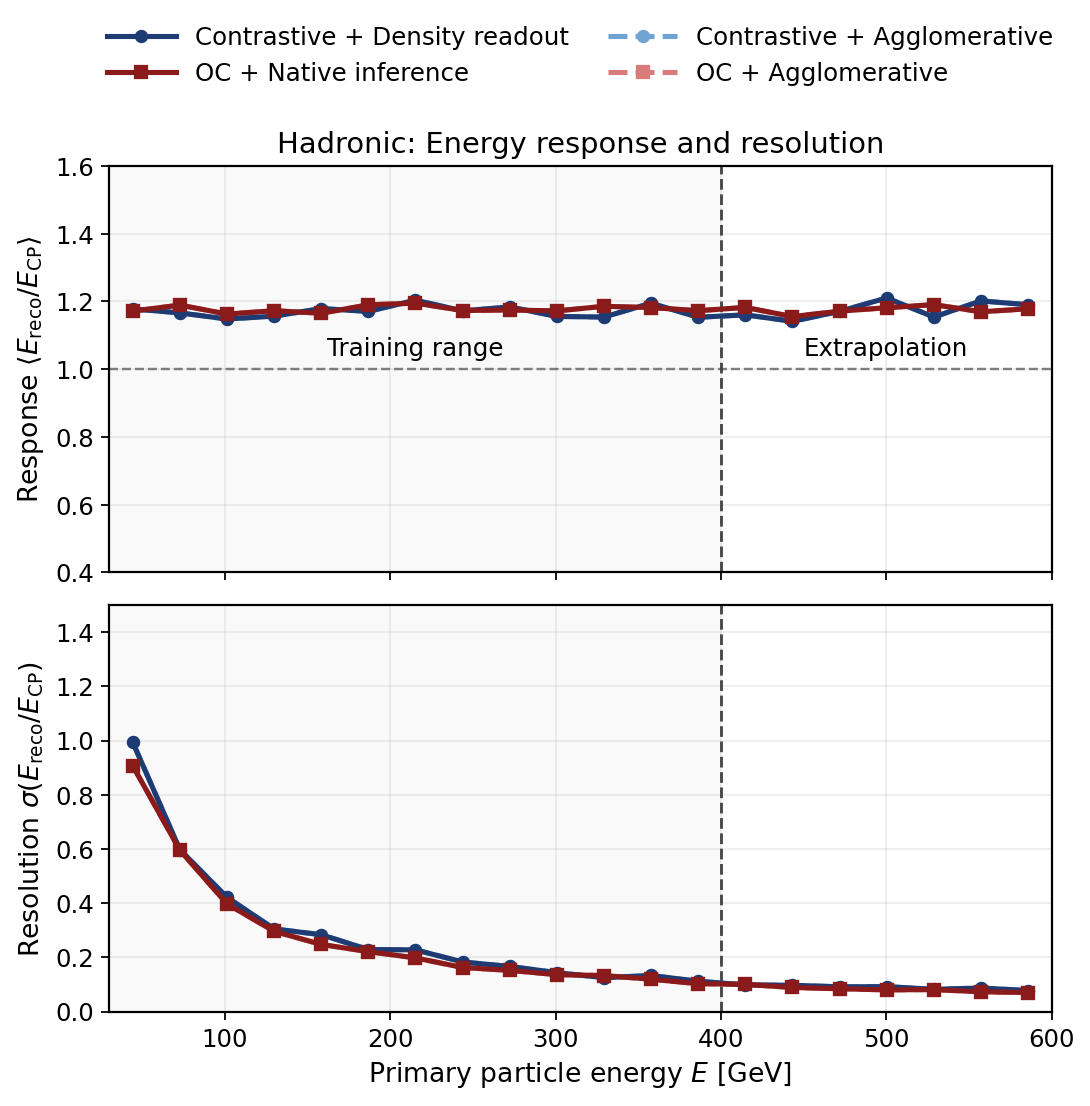

In [11]:

EVENT_COL      = "event_id"
CP_ID_COL      = "cp_id"
PRIMARY_E_COL  = "PrimaryEnergy"  
CP_E_COL       = "cp_energy"     
RECO_E_COL     = "reco_energy"    
SHARED_COL     = "shared_energy"  


METHODS = [
    ("Contrastive + Density readout",  df_oc_noise),  
    ("OC + Native inference",          df_oc),      
    ("Contrastive + Agglomerative",    df_contrastive),
    ("OC + Agglomerative",             df_oc_Ag), 
]

BLUE_DARK  = "#1f3b73"
BLUE_LIGHT = "#6fa3d2"
RED_DARK   = "#8b1a1a"
RED_LIGHT  = "#d97b7b"

STYLE = {
    "Contrastive + Density readout": dict(color=BLUE_DARK,  linestyle="-",  marker="o", zorder=5),
    "OC + Native inference":         dict(color=RED_DARK,   linestyle="-",  marker="s", zorder=5),
    "Contrastive + Agglomerative":   dict(color=BLUE_LIGHT, linestyle="--", marker="o", zorder=3),
    "OC + Agglomerative":            dict(color=RED_LIGHT,  linestyle="--", marker="s", zorder=3),
}


n_bins = 20
E_MIN_GEV = 30.0
E_MAX_GEV = 600.0

energy_bins = np.linspace(E_MIN_GEV * 1000.0, E_MAX_GEV * 1000.0, n_bins + 1)  # MeV
energy_bin_centers = 0.5 * (energy_bins[:-1] + energy_bins[1:])
xE_GeV = energy_bin_centers / 1000.0


def response_by_energy_bin(
    df,
    energy_bins_mev,
    *,
    primary_e_col=PRIMARY_E_COL,
    event_col=EVENT_COL,
    cp_col=CP_ID_COL,
    shared_col=SHARED_COL,
    cp_e_col=CP_E_COL,
    reco_e_col=RECO_E_COL,
    max_events=5000,
    random_state=42,
    ratio_lo=0.0,
    ratio_hi=3,
):
    response_bins = []
    mean_response = []
    resolution = []

    for i in range(len(energy_bins_mev) - 1):
        low, high = energy_bins_mev[i], energy_bins_mev[i + 1]

        df_bin = df[
            (df[primary_e_col] >= low) &
            (df[primary_e_col] < high)
        ]

        responses = []

        event_groups = list(df_bin.groupby(event_col))

        if max_events is not None and len(event_groups) > max_events:
            rng = np.random.default_rng(random_state)
            idx = rng.choice(len(event_groups), size=max_events, replace=False)
            event_groups = [event_groups[j] for j in idx]

        for _, df_evt in event_groups:
            for _, df_cp in df_evt.groupby(cp_col):
                best = df_cp.loc[df_cp[shared_col].idxmax()]

                cp_E   = best[cp_e_col]
                reco_E = best[reco_e_col]

                if cp_E > 0:
                    ratio = reco_E / cp_E
                    if ratio_lo <= ratio <= ratio_hi:
                        responses.append(ratio)

        responses = np.asarray(responses, dtype=float)
        response_bins.append(responses)

        if len(responses):
            mean_response.append(float(np.mean(responses)))
            resolution.append(float(np.std(responses)))
        else:
            mean_response.append(np.nan)
            resolution.append(np.nan)

    return response_bins, np.asarray(mean_response), np.asarray(resolution)

resp_bins = {}
mean_resp = {}
std_resp  = {}

for name, df in METHODS:
    rb, mu, sig = response_by_energy_bin(df, energy_bins)
    resp_bins[name] = rb
    mean_resp[name] = mu
    std_resp[name]  = sig


fig, (ax_resp, ax_res) = plt.subplots(
    2, 1, figsize=(7.6, 7.0),
    sharex=True,
    gridspec_kw={"height_ratios": [1.0, 1.0], "hspace": 0.08},
)

#Response (top)
for name, _df in METHODS:
    ax_resp.plot(xE_GeV, mean_resp[name], label=name, **STYLE[name])

ax_resp.set_title("Hadronic: Energy response and resolution")
ax_resp.set_ylabel(r"Response $\langle E_\mathrm{reco}/E_\mathrm{CP} \rangle$")
ax_resp.axhline(1.0, color="0.35", linestyle="--", linewidth=1.1, alpha=0.75)
ax_resp.set_ylim(0.4, 1.6)  # adjust if needed
_major_grid(ax_resp)

# --- Resolution (bottom)

E_cent_mev = energy_bin_centers
E_cent_gev = xE_GeV

for name, _df in METHODS:
    y = (std_resp[name] * 1000.0 * 100.0) / E_cent_mev  
    ax_res.plot(E_cent_gev, y, label=name, **STYLE[name])

ax_res.set_ylabel(r"Resolution $(\sigma \times 1000 \times 100) / E_\mathrm{bin}$")
ax_res.set_xlabel(r"Primary particle energy $E$ [GeV]")
ax_res.set_ylabel(r"Resolution $\sigma(E_\mathrm{reco}/E_\mathrm{CP})$")
ax_res.set_ylim(0.0, 1.5)  
_major_grid(ax_res)

ax_res.set_xlim(E_MIN_GEV, E_MAX_GEV)

split_GeV = 400.0
xmin, xmax = E_MIN_GEV, E_MAX_GEV

for ax in (ax_resp, ax_res):
    ax.axvline(split_GeV, color="0.25", linestyle="--", linewidth=1.3, alpha=0.95)
    ax.axvspan(xmin, split_GeV, color="0.3", alpha=0.03, lw=0)
    ax.axvspan(split_GeV, xmax, color="0.3", alpha=0.00, lw=0)

ax_resp.text(
    0.5 * (xmin + split_GeV),
    0.55,
    "Training range",
    ha="center",
    va="center",
    transform=ax_resp.get_xaxis_transform(),
    fontsize=11,
)
ax_resp.text(
    0.5 * (split_GeV + xmax),
    0.55,
    "Extrapolation",
    ha="center",
    va="center",
    transform=ax_resp.get_xaxis_transform(),
    fontsize=11,
)

ax_resp.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.40),
    ncol=2,
    columnspacing=1.6,
    handlelength=2.8,
)

plt.tight_layout()
plt.show()

# Optional save:
fig.savefig("Had_response.pdf", bbox_inches="tight")
# fig.savefig("response_resolution_vs_energy_publish.png", bbox_inches="tight")